In [158]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pmdarima as pm
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [159]:
df=pd.read_csv('cleaned_online_retail.csv')

In [160]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [161]:
df['InvoiceDate'] = df['InvoiceDate'].dt.date

In [162]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [163]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01,3.39,17850.0,United Kingdom,20.34


<Axes: >

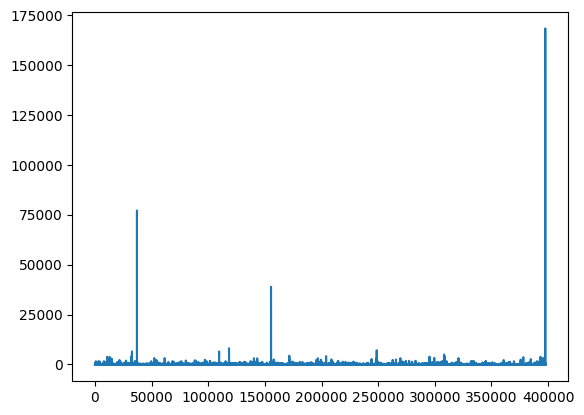

In [164]:
df['TotalPrice'].plot()

In [165]:
df['TotalPrice'].describe()

count    397924.000000
mean         22.394749
std         309.055588
min           0.000000
25%           4.680000
50%          11.800000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

(0.0, 5000.0)

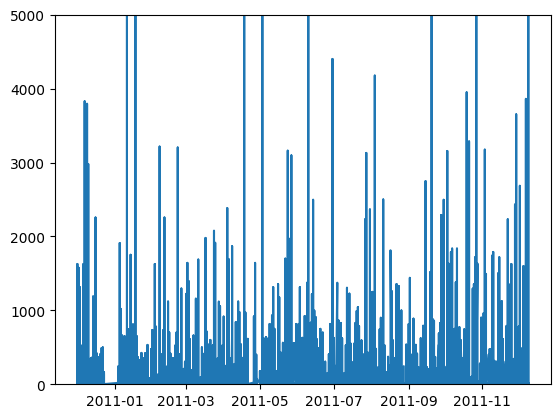

In [166]:
plt.plot(df['InvoiceDate'],df['TotalPrice'])
plt.ylim(0, 5000)

### Univariate Analysis

In [167]:
daily_sales = df.groupby('InvoiceDate')['TotalPrice'].sum()
print(daily_sales.head())

InvoiceDate
2010-12-01    46376.49
2010-12-02    47316.53
2010-12-03    23921.71
2010-12-05    31771.60
2010-12-06    31215.64
Name: TotalPrice, dtype: float64


In [168]:
daily_sales.describe()

count       305.000000
mean      29217.730833
std       17854.997860
min        3457.110000
25%       18021.481000
50%       25489.660000
75%       36751.250000
max      184349.280000
Name: TotalPrice, dtype: float64

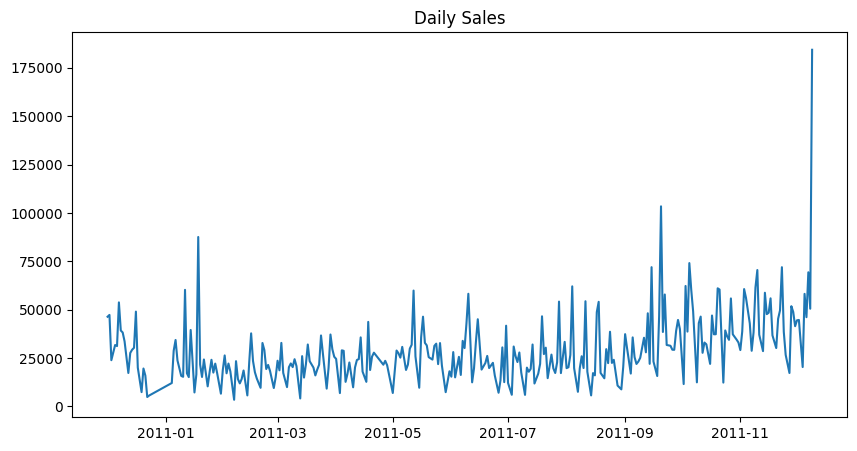

In [169]:
plt.figure(figsize=(10,5))
plt.plot(daily_sales)
plt.title("Daily Sales")
plt.show()

In [170]:
daily_sales.shape

(305,)

In [171]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(daily_sales)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -0.366093
p-value: 0.915608


In [172]:
from statsmodels.tsa.stattools import kpss
result_sales = kpss(daily_sales)
print("KPSS Statistic:", result_sales[0])
print("p-value:", result_sales[1])

KPSS Statistic: 1.899550618616463
p-value: 0.01


C:\Users\Pratham\AppData\Local\Temp\ipykernel_31000\4071706123.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result_sales = kpss(daily_sales)


<Axes: xlabel='TotalPrice'>

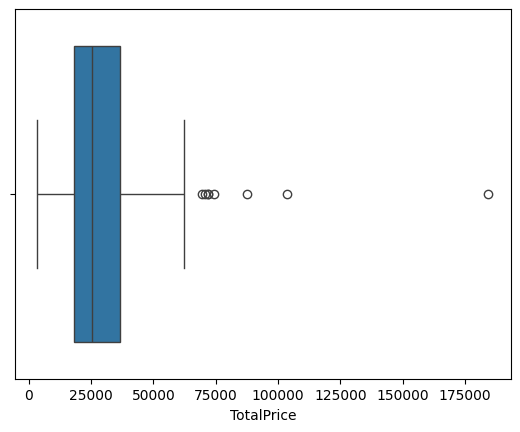

In [173]:
sns.boxplot(x=daily_sales)

### ARIMA

In [175]:
train_data = daily_sales.iloc[:-30]
test_data = daily_sales.iloc[-30:]

In [176]:
print("Searching for the optimal SARIMA parameters...")
best_model = pm.auto_arima(
    train_data,
    seasonal=True,
    m=7,                     # Weekly seasonality 
    d=None,                  # Let the algorithm determine standard differencing
    D=None,                  # Let the algorithm determine seasonal differencing
    trace=True,              # Prints the grid search progress
    error_action='ignore',  
    suppress_warnings=True, 
    stepwise=True            # Uses a smart search algorithm to save time
)

Searching for the optimal SARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=5994.725, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=6145.636, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=6096.851, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=6001.886, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=6143.639, Time=0.01 sec
 ARIMA(2,1,2)(0,0,1)[7] intercept   : AIC=5994.130, Time=0.28 sec
 ARIMA(2,1,2)(0,0,0)[7] intercept   : AIC=5996.998, Time=0.10 sec
 ARIMA(2,1,2)(0,0,2)[7] intercept   : AIC=5992.095, Time=0.40 sec
 ARIMA(2,1,2)(1,0,2)[7] intercept   : AIC=5991.714, Time=0.59 sec
 ARIMA(2,1,2)(2,0,2)[7] intercept   : AIC=5993.419, Time=0.88 sec
 ARIMA(2,1,2)(2,0,1)[7] intercept   : AIC=5992.725, Time=0.78 sec
 ARIMA(1,1,2)(1,0,2)[7] intercept   : AIC=5993.314, Time=0.32 sec
 ARIMA(2,1,1)(1,0,2)[7] intercept   : AIC=5997.803, Time=0.31 sec
 ARIMA(3,1,2)(1,0,2)[7] intercept   : AIC=5994.215, 

In [177]:
print(best_model.summary())

                                       SARIMAX Results                                        
Dep. Variable:                                      y   No. Observations:                  275
Model:             SARIMAX(2, 1, 3)x(0, 0, [1, 2], 7)   Log Likelihood               -2983.980
Date:                                Sat, 11 Apr 2026   AIC                           5983.961
Time:                                        12:26:44   BIC                           6012.866
Sample:                                             0   HQIC                          5995.563
                                                - 275                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3476      0.057    -23.843      0.000      -1.458      -1.237
ar.

In [178]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

forecast, conf_int = best_model.predict(n_periods=len(test_data), return_conf_int=True)
forecast_index = test_data.index

# 4. Evaluate Model Performance
mae = mean_absolute_error(test_data, forecast)
rmse = np.sqrt(mean_squared_error(test_data, forecast))
print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


--- Model Evaluation ---
Mean Absolute Error (MAE): 15723.29
Root Mean Squared Error (RMSE): 29633.04


C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Pratham\AppData\Roaming\Python\Python312\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


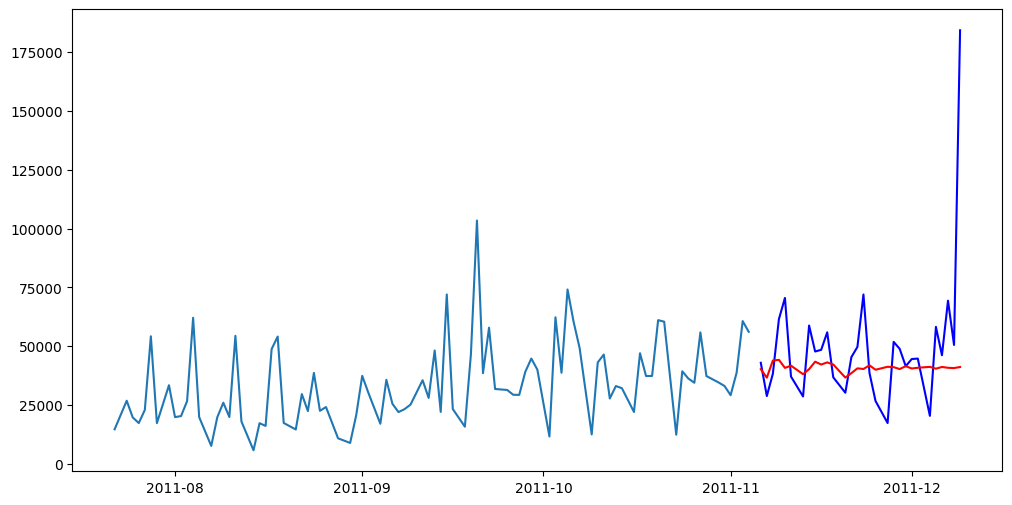

In [179]:
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-90:], train_data[-90:], label='Training Data') 
plt.plot(test_data.index, test_data, label='Actual Test Data', color='blue')
plt.plot(forecast_index, forecast, label='Forecast', color='red')

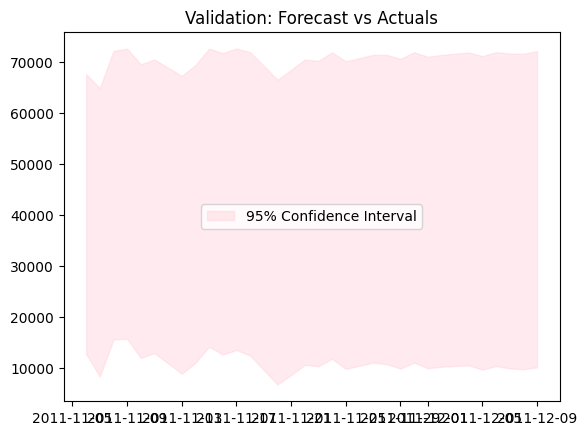

In [180]:
plt.fill_between(
    forecast_index, 
    conf_int[:, 0], 
    conf_int[:, 1], 
    color='pink', alpha=0.3, label='95% Confidence Interval'
)

plt.title("Validation: Forecast vs Actuals")
plt.legend()
plt.show()

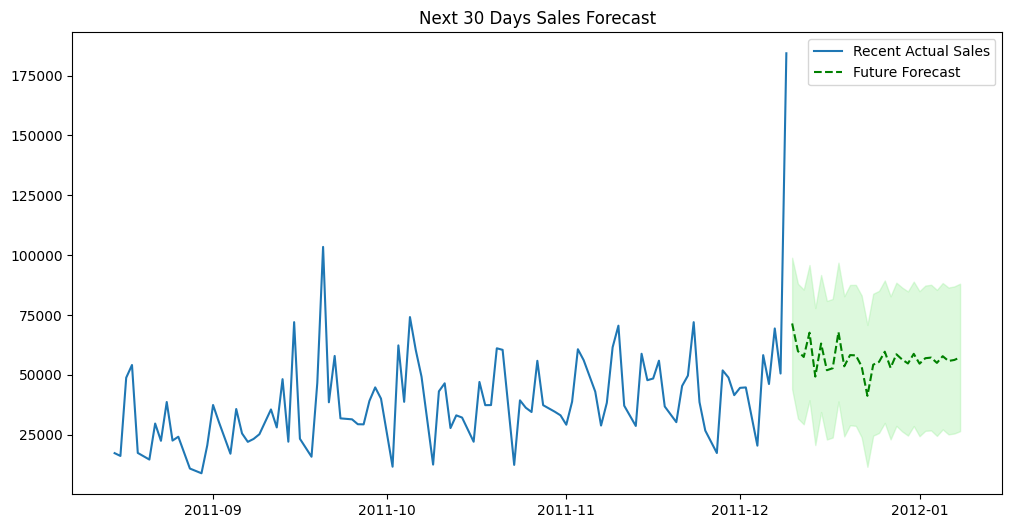

In [181]:
best_model.update(test_data)

future_steps = 30
future_forecast, future_conf_int = best_model.predict(n_periods=future_steps, return_conf_int=True)
future_index = pd.date_range(start=daily_sales.index[-1] + pd.Timedelta(days=1), periods=future_steps, freq='D')


plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index[-100:], daily_sales[-100:], label='Recent Actual Sales')
plt.plot(future_index, future_forecast, label='Future Forecast', color='green', linestyle='--')
plt.fill_between(
    future_index, 
    future_conf_int[:, 0], 
    future_conf_int[:, 1], 
    color='lightgreen', alpha=0.3
)
plt.title(f"Next {future_steps} Days Sales Forecast")
plt.legend()
plt.show()

### Prophet

In [182]:
df=pd.read_csv('cleaned_online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [183]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSales'] = df['UnitPrice'] * df['Quantity']

In [184]:
hourly_df = df.set_index('InvoiceDate')['TotalSales'].resample('H').sum().reset_index()

C:\Users\Pratham\AppData\Local\Temp\ipykernel_31000\2038691088.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_df = df.set_index('InvoiceDate')['TotalSales'].resample('H').sum().reset_index()


In [185]:

from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error


print(f"Max hourly sale before capping: £{hourly_df['TotalSales'].max():.2f}")
print(f"Number of hours with negative sales (returns): {(hourly_df['TotalSales'] < 0).sum()}")


hourly_df['CleanedSales'] = np.where(hourly_df['TotalSales'] < 0, 0, hourly_df['TotalSales'])
ceiling_value = hourly_df['CleanedSales'].quantile(0.95)
print(f"Capping all extreme outlier hours at: £{ceiling_value:.2f}")


Max hourly sale before capping: £171679.08
Number of hours with negative sales (returns): 0
Capping all extreme outlier hours at: £4991.07


In [186]:
# 4. Apply the Cap
hourly_df['CappedSales'] = np.where(
    hourly_df['CleanedSales'] > ceiling_value, 
    ceiling_value, 
    hourly_df['CleanedSales']
)

In [187]:
prophet_df = hourly_df[['InvoiceDate', 'CappedSales']]
prophet_df.columns = ['ds', 'y']

prophet_df['y_log'] = np.log1p(prophet_df['y'])

train_df = prophet_df[['ds', 'y_log']].rename(columns={'y_log': 'y'})
test_df = prophet_df.iloc[-holdout_hours:] 

train_data = train_df.iloc[:-holdout_hours]

C:\Users\Pratham\AppData\Local\Temp\ipykernel_31000\1865047487.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prophet_df['y_log'] = np.log1p(prophet_df['y'])


In [188]:

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=True
)
model.fit(train_data)

12:26:45 - cmdstanpy - INFO - Chain [1] start processing
12:26:45 - cmdstanpy - INFO - Chain [1] done processing


In [189]:
future_test = model.make_future_dataframe(periods=holdout_hours, freq='h')
forecast = model.predict(future_test)


log_predictions = forecast.iloc[-holdout_hours:]['yhat']
real_predictions = np.expm1(log_predictions)
real_actuals = test_df['y']

# 6. Evaluate
mae = mean_absolute_error(real_actuals, real_predictions)
rmse = np.sqrt(mean_squared_error(real_actuals, real_predictions))

print("\n--- Log-Transformed Prophet Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")



--- Log-Transformed Prophet Evaluation ---
Mean Absolute Error (MAE): 884.35
Root Mean Squared Error (RMSE): 1671.70


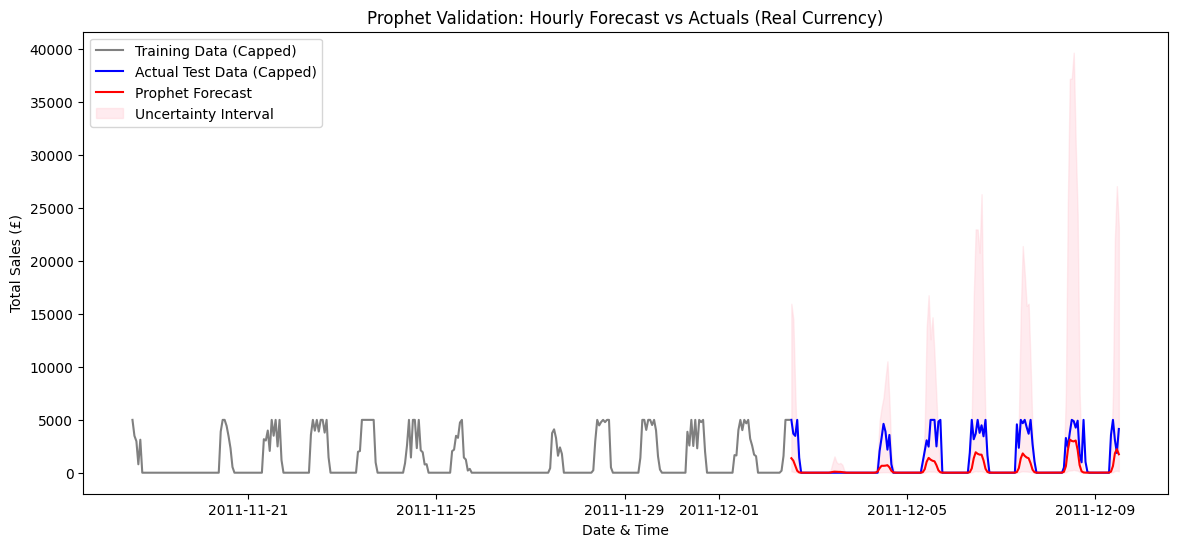

In [190]:
holdout_hours = 168 

plt.figure(figsize=(14, 6))
real_train_y = np.expm1(train_data['y'])
plt.plot(train_data['ds'][-336:], real_train_y[-336:], label='Training Data (Capped)', color='gray')

plt.plot(test_df['ds'], test_df['y'], label='Actual Test Data (Capped)', color='blue')
plt.plot(test_df['ds'], real_predictions, label='Prophet Forecast', color='red')

real_yhat_lower = np.expm1(forecast.iloc[-holdout_hours:]['yhat_lower'])
real_yhat_upper = np.expm1(forecast.iloc[-holdout_hours:]['yhat_upper'])

plt.fill_between(
    test_df['ds'], 
    real_yhat_lower, 
    real_yhat_upper, 
    color='pink', alpha=0.3, label='Uncertainty Interval'
)

plt.title("Prophet Validation: Hourly Forecast vs Actuals (Real Currency)")
plt.xlabel("Date & Time")
plt.ylabel("Total Sales (£)")
plt.legend()
plt.show()

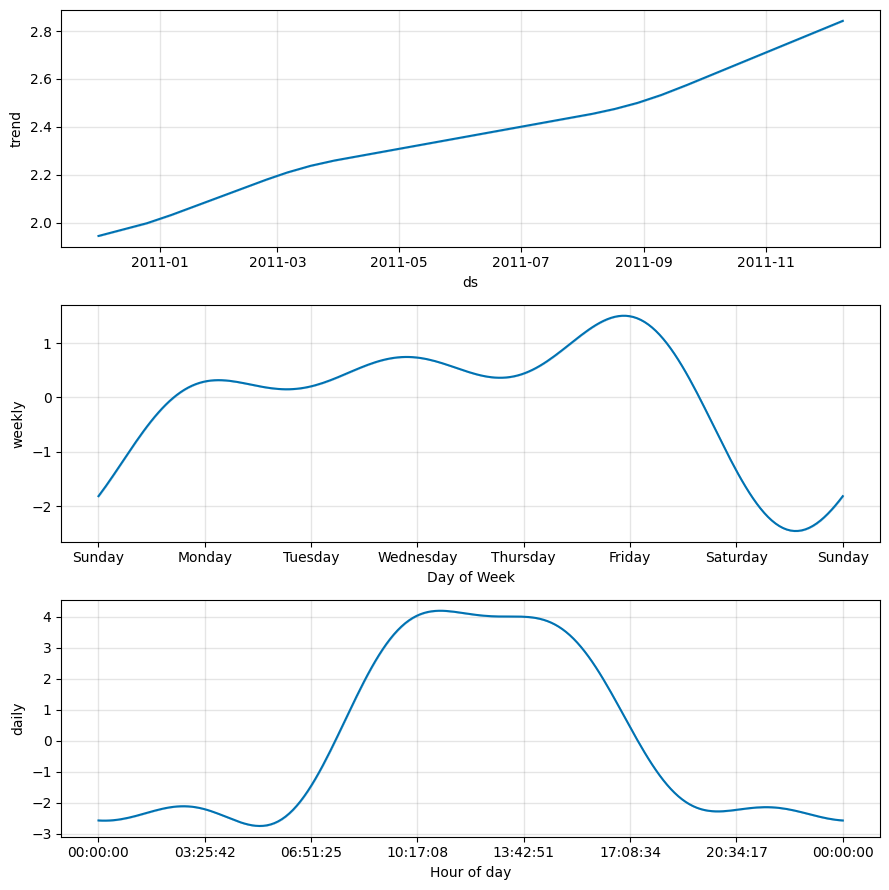

In [191]:
fig = model.plot_components(forecast)
plt.show()